# Bias–Variance Tradeoff with Polynomial Regression

This notebook simulates a simple regression problem where the true data-generating
relationship is cubic. We then fit polynomials of various degrees to illustrate:

- Underfitting: linear model (too simple).
- "Correct" complexity: cubic model.
- Overfitting: high-degree polynomials that fit training data very well but generalize poorly.
- The classic U-shaped curve of test error vs. model complexity (degree).


In [114]:
import numpy as np
import matplotlib.pyplot as plt

from typing import Callable, Tuple, Dict

plt.rcParams.update({
    "figure.figsize": (7, 6),
    "axes.grid": True,
    "font.size": 11
})

## 1. Define the true data-generating process

We use a cubic function plus Gaussian noise:

$$
y = f(x) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2)
$$

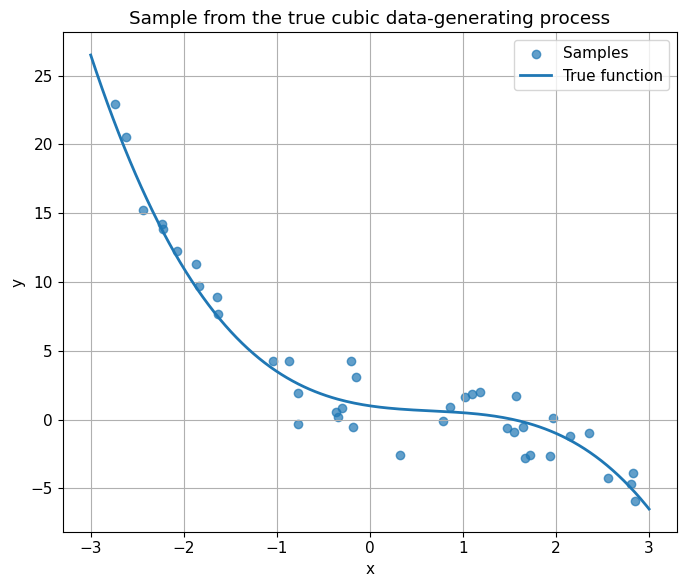

In [115]:
def true_function(x: np.ndarray) -> np.ndarray:
    """
    Underlying true cubic relationship.
    Feel free to tweak coefficients if you want a different shape.
    """
    return - 0.5*  x**3 + x**2 -  x + 1


def generate_data(
    n: int,
    x_min: float = -3.0,
    x_max: float = 3.0,
    noise_std: float = 2.0,
    rng: np.random.Generator | None = None
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate (x, y) pairs from the cubic model plus Gaussian noise.
    """
    if rng is None:
        rng = np.random.default_rng()

    x = rng.uniform(x_min, x_max, size=n)
    x = np.sort(x)
    noise = rng.normal(loc=0.0, scale=noise_std, size=n)
    y = true_function(x) + noise
    return x, y


# Quick sanity check plot (optional)
rng = np.random.default_rng(42)
x_demo, y_demo = generate_data(40, rng=rng)

x_grid = np.linspace(-3, 3, 200)
plt.scatter(x_demo, y_demo, alpha=0.7, label="Samples")
plt.plot(x_grid, true_function(x_grid), label="True function", linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Sample from the true cubic data-generating process")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Polynomial regression helpers

We'll use NumPy's `polyfit` / `polyval` to fit polynomials of a given degree.


In [116]:
def fit_polynomial(x: np.ndarray, y: np.ndarray, degree: int) -> np.ndarray:
    """
    Fit a polynomial of given degree to (x, y) using least squares.
    Returns the coefficients in descending powers (as in np.polyval).
    """
    coeffs = np.polyfit(x, y, deg=degree)
    return coeffs


def predict_polynomial(coeffs: np.ndarray, x: np.ndarray) -> np.ndarray:
    """
    Evaluate a fitted polynomial at given x values.
    """
    return np.polyval(coeffs, x)


def mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Mean squared error.
    """
    return float(np.mean((y_true - y_pred) ** 2))

## 3. Visualizing underfitting and overfitting

We generate one training and one test set, then fit:

- Degree 1 (linear – underfitting)
- Degree 3 (cubic – correctly specified)
- Degree 10 (high-degree – overfitting)

We show the fits on both the training and test data.

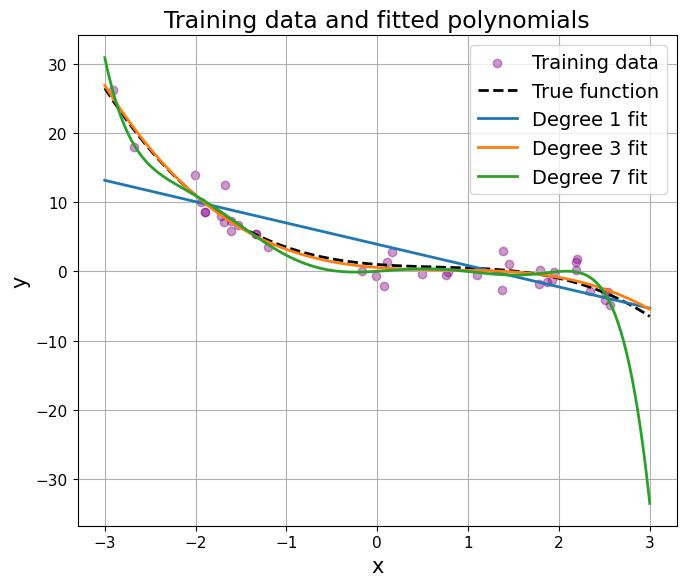

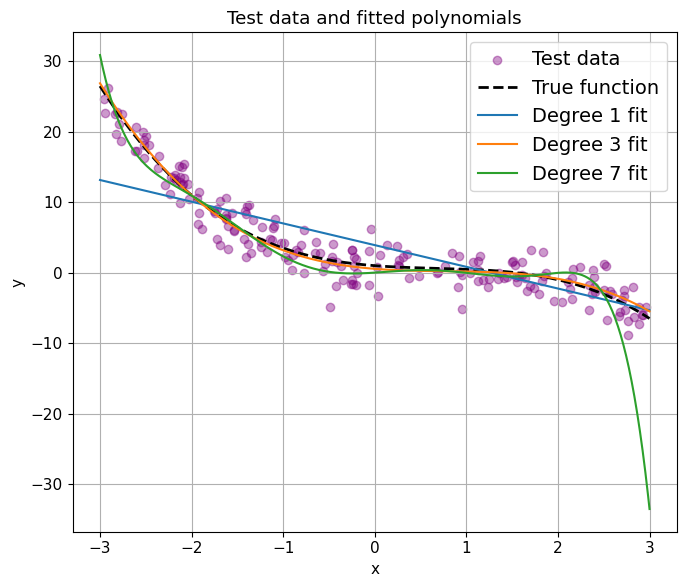

Degree 1: train MSE = 11.537, test MSE = 14.777
Degree 3: train MSE = 2.759, test MSE = 4.319
Degree 7: train MSE = 2.179, test MSE = 17.046


In [132]:
rng = np.random.default_rng(123)

# Generate one train/test split
x_train, y_train = generate_data(n=40, rng=rng)
x_test, y_test = generate_data(n=200, rng=rng)

degrees_to_show = [1, 3, 7]
models: Dict[int, np.ndarray] = {}

for d in degrees_to_show:
    coeffs = fit_polynomial(x_train, y_train, degree=d)
    models[d] = coeffs

# Grid for smooth curves
x_grid = np.linspace(-3, 3, 400)
y_true_grid = true_function(x_grid)

# Plot 1: Training data + fits
plt.figure()
plt.scatter(x_train, y_train, alpha=0.4, label="Training data", color="purple")
plt.plot(x_grid, y_true_grid, "k--", label="True function", linewidth=2)

for d, coeffs in models.items():
    y_fit_grid = predict_polynomial(coeffs, x_grid)
    plt.plot(x_grid, y_fit_grid, label=f"Degree {d} fit", linewidth=2)

plt.xlabel("x", fontsize=15)
plt.ylabel("y", fontsize=15)
plt.title("Training data and fitted polynomials", fontsize=17)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig("bias_variance_tradeoff_training.pdf")
plt.show()

# Plot 2: Test data + fits
plt.figure()
plt.scatter(x_test, y_test, alpha=0.4, label="Test data", color="purple")
plt.plot(x_grid, y_true_grid, "k--", label="True function", linewidth=2)

for d, coeffs in models.items():
    y_fit_grid = predict_polynomial(coeffs, x_grid)
    plt.plot(x_grid, y_fit_grid, label=f"Degree {d} fit")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Test data and fitted polynomials")
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# Compute and print MSEs for these three models
for d, coeffs in models.items():
    train_mse = mse(y_train, predict_polynomial(coeffs, x_train))
    test_mse = mse(y_test, predict_polynomial(coeffs, x_test))
    print(f"Degree {d}: train MSE = {train_mse:.3f}, test MSE = {test_mse:.3f}")

## 4. Bias–variance tradeoff via multiple simulations

We now:

1. Choose a range of model complexities (polynomial degrees).
2. Repeat the following experiment many times:
   - Generate a new training set.
   - Fit each degree.
   - Record training and test MSE.
3. Average over repetitions.

We then plot:
- Training error vs. degree (typically decreasing).
- Test error vs. degree (typically U-shaped).


In [118]:
def simulate_errors_over_degrees(
    degrees: list[int],
    n_train: int = 40,
    n_test: int = 400,
    n_reps: int = 200,
    noise_std: float = 2.0,
    seed: int = 0,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Simulate training and test errors for each polynomial degree.

    Returns:
        mean_train_mse: [len(degrees)]
        std_train_mse:  [len(degrees)]
        mean_test_mse:  [len(degrees)]
        std_test_mse:   [len(degrees)]
    """
    rng = np.random.default_rng(seed)

    train_errors = np.zeros((len(degrees), n_reps))
    test_errors = np.zeros((len(degrees), n_reps))

    # Fixed test set across repetitions for cleaner comparison
    x_test, y_test = generate_data(n=n_test, noise_std=noise_std, rng=rng)

    for rep in range(n_reps):
        x_train, y_train = generate_data(n=n_train, noise_std=noise_std, rng=rng)

        for i, d in enumerate(degrees):
            coeffs = fit_polynomial(x_train, y_train, degree=d)

            y_pred_train = predict_polynomial(coeffs, x_train)
            y_pred_test = predict_polynomial(coeffs, x_test)

            train_errors[i, rep] = mse(y_train, y_pred_train)
            test_errors[i, rep] = mse(y_test, y_pred_test)

    mean_train = train_errors.mean(axis=1)
    std_train = train_errors.std(axis=1)

    mean_test = test_errors.mean(axis=1)
    std_test = test_errors.std(axis=1)

    return mean_train, std_train, mean_test, std_test


degrees = list(range(1, 8))  # degrees 1 to 12
mean_train, std_train, mean_test, std_test = simulate_errors_over_degrees(
    degrees=degrees,
    n_train=40,
    n_test=400,
    n_reps=200,
    noise_std=2.0,
    seed=2025,
)

## 5. The classic U-shaped error curve

We plot mean training and test MSE vs. degree. You should see:

- Training error monotonically decreasing with degree.
- Test error initially decreasing, then increasing again as overfitting kicks in.
- Degree 3 (cubic) performing best or close to best on the test set.
- Degree 1 (linear) clearly underfitting (high bias).


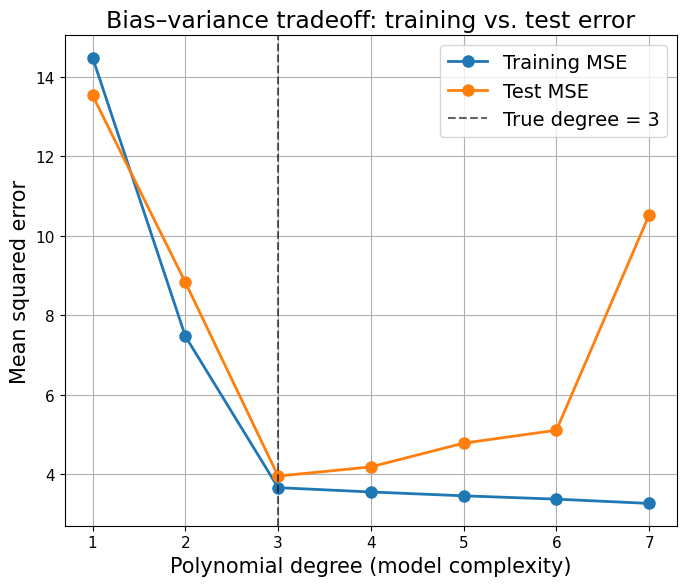

Degree with lowest average test MSE: 3


In [130]:
degrees_array = np.array(degrees)

plt.figure()
plt.plot(degrees_array, mean_train, marker="o", label="Training MSE", linewidth=2, markersize=8)
plt.plot(degrees_array, mean_test, marker="o", label="Test MSE", linewidth=2, markersize=8)

# Optional error bars (±1 std)


plt.axvline(3, color="k", linestyle="--", alpha=0.6, label="True degree = 3")

plt.xlabel("Polynomial degree (model complexity)", fontsize=15)
plt.ylabel("Mean squared error", fontsize=15)
plt.title("Bias–variance tradeoff: training vs. test error", fontsize=17)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig("bias_variance_tradeoff_errors.pdf")
plt.show()

# Print out which degree has minimal test error
best_degree = degrees_array[np.argmin(mean_test)]
print(f"Degree with lowest average test MSE: {best_degree}")

## 6. Summary

- **Linear model (degree 1)**: too simple → systematic miss of the cubic pattern ⇒ high bias.
- **Cubic model (degree 3)**: matches the true functional form ⇒ good bias–variance tradeoff.
- **High-degree models (e.g., degree 10–12)**: can fit the training data extremely well, but
  small changes in the training sample cause large changes in the fitted function ⇒ high variance,
  leading to worse test performance.

You can play with:
- `noise_std` (higher noise → stronger variance effects),
- `n_train` (more data reduces variance),
- `n_reps` (smoother curves but more computation),
- the coefficients in `true_function`.
